# Phishing Detection — A Critical Evaluation of the "99% Accuracy" Claim

**Course:** Data Science Methods in Cyber Security (University of Haifa) · Dr. Uri Itai

**Source under evaluation:** Al-Subaiey et al., *"Novel Interpretable and Robust Web-based
AI Platform for Phishing Email Detection"* ([arXiv:2405.11619](https://arxiv.org/abs/2405.11619)) —
which reports **99.1% accuracy / 0.99 F1** with TF-IDF + a Linear SVM on a merged
multi-corpus email dataset, reporting accuracy/precision/recall/F1 but **no MCC, no
ROC-AUC, and no cross-corpus generalization test**.

**Our question.** We reproduce the headline result, then ask whether it reflects
*generalizable phishing detection* or merely *in-distribution performance on this
particular pool of corpora*. This notebook covers **data loading** and **exploratory
data analysis**; the feature engineering, modeling, and the critical-evaluation
experiments follow in later sections.

## 0. Setup

Imports, fixed seed, and a path bootstrap so the notebook runs whether it is launched from the repo root or from `notebooks/`.

In [1]:
import os
import sys
from pathlib import Path

# Make the repo root importable / the working directory, regardless of launch dir.
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

from src import config, critique, data, evaluate, features, models, plots

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 120)
np.random.seed(config.RANDOM_SEED)
print("repo root:", ROOT)
print("random seed:", config.RANDOM_SEED)

repo root: D:\HaifaUni\Cyber Security\Project\phishing-detection-ds-cyber
random seed: 42


## 1. Data Loading

The dataset is the **"Phish No More"** collection (Kaggle: `naserabdullahalam/phishing-email-dataset`),
the source paper's own dataset. It merges six well-known research corpora. We load each
corpus separately and **tag every email with its corpus of origin** — that `corpus`
column is the linchpin of the entire critique, because it lets us later ask whether the
model is detecting *phishing* or *provenance*.

In [2]:
merged = data.build_merged()
print("rows, columns:", merged.shape)
(
    merged.assign(text_preview=merged[config.TEXT_COL].str[:80])
    [[config.CORPUS_COL, config.LABEL_COL, "date", "text_preview"]]
    .head(8)
)

rows, columns:

 (82486, 4)


,corpus,label,date,text_preview
0,Enron,0,NaT,"hpl nom for may 25 , 2001 ( see attached file : hplno 525 . xls )\r\n- hplno 525 ."
1,Enron,0,NaT,re : nom / actual vols for 24 th - - - - - - - - - - - - - - - - - - - - - - for
2,Enron,0,NaT,"enron actuals for march 30 - april 1 , 201 estimated actuals\r\nmarch 30 , 2001\r\nn"
3,Enron,0,NaT,"hpl nom for may 30 , 2001 ( see attached file : hplno 530 . xls )\r\n- hplno 530 ."
4,Enron,0,NaT,"hpl nom for june 1 , 2001 ( see attached file : hplno 601 . xls )\r\n- hplno 601 ."
5,Enron,0,NaT,hpl nom for may 31 2001 ( see attached file : hplno 531 . xls )\r\n- hplno 531 . x
6,Enron,0,NaT,# 9760 tried to get fancy with your address and it came back to me !\r\n- - - - -
7,Enron,0,NaT,"hpl noms for february 15 , 2000 ( see attached file : hplo 215 . xls )\r\n- hplo 2"


### 1.1 Size and feature types

In [3]:
print("memory (MB):", round(merged.memory_usage(deep=True).sum() / 1e6, 1))
merged.dtypes

memory (MB): 182.1


text      object
label      int32
date      object
corpus    object
dtype: object

The frame is intentionally minimal: a free-text field (`text` = subject + body), a binary
`label` (1 = phishing, 0 = legitimate), the `corpus` tag we attached, and an optional
`date`. Everything downstream is derived from `text`; `corpus` and `date` are kept for the
critique (provenance and temporal analyses), **not** as model inputs.

### 1.2 Missing values

In [4]:
merged.isna().sum()

text          0
label         0
date      35532
corpus        0
dtype: int64

Only `date` is missing — and its missingness is **informative, not random**: as we show
below, the legitimate-bearing corpora (Enron, Ling) ship with no timestamps at all. This
is a data-quality fact we must respect (it constrains any temporal analysis), exactly the
kind of "*why* is it missing?" question the EDA-Revisited lecture stresses.

### 1.3 Index and column sanity, single-value and duplicate features

In [5]:
print("columns:", list(merged.columns))
print("index is unique:", merged.index.is_unique)
print("\nunique values per column:")
print(merged.nunique())
print("\nfully duplicated rows:", int(merged.duplicated().sum()))
print("duplicated text bodies:", int(merged[config.TEXT_COL].duplicated().sum()))

columns: ['text', 'label', 'date', 'corpus']
index is unique: True

unique values per column:


text      82441
label         2
date      43316
corpus        6
dtype: int64



fully duplicated rows: 23
duplicated text bodies: 45


- **No single-value columns** (none would be useless constants) and **no index masquerading
  as a feature** (the index is a clean RangeIndex; `text` is high-cardinality as expected for
  free text).
- There are some **duplicated text bodies**. Duplicates inflate in-distribution scores if the
  same email lands in both train and test, so we flag this now (tracked in
  `docs/KNOWN_LIMITATIONS.md`) and revisit it when we evaluate.

### 1.4 Temporal coverage

In [6]:
coverage = (
    merged.assign(has_date=merged["date"].notna())
    .groupby(config.CORPUS_COL)
    .agg(n=("date", "size"), with_date=("has_date", "sum"))
)
coverage["pct_dated"] = (coverage["with_date"] / coverage["n"] * 100).round(1)
date_range = (
    merged.dropna(subset=["date"]).groupby(config.CORPUS_COL)["date"].agg(["min", "max"])
)
display(coverage)
display(date_range)

,n,with_date,pct_dated
corpus,,,
CEAS,39154,39139,100.0
Enron,29767,0,0.0
Ling,2859,0,0.0
Nazario,1565,405,25.9
Nigerian_Fraud,3332,2850,85.5
SpamAssassin,5809,4560,78.5


,min,max
corpus,,
CEAS,1980-01-04 05:39:00+00:00,2100-05-27 19:54:05+00:00
Nazario,2015-12-10 14:52:28+00:00,2022-12-27 02:56:49+00:00
Nigerian_Fraud,1980-01-03 10:02:05+00:00,2082-04-02 12:31:31+00:00
SpamAssassin,1997-01-04 00:24:47+00:00,2028-10-04 16:05:01+00:00


**World-knowledge check.** Dates exist only for the phishing/spam-heavy corpora (CEAS-08,
Nazario, Nigerian-Fraud, SpamAssassin); the ham-bearing Enron and Ling corpora are undated.
Note also a **data-quality red flag**: CEAS-08 should be a 2008 corpus, but its timestamps
range from **1980 to 2100** — impossible dates that signal corrupt/sentinel values (the kind
of issue the EDA-Revisited lecture warns about). This matters three ways: (i) a clean
*cross-class* train-on-past / test-on-future split is impossible (the legitimate side has no
time axis), so our temporal experiment is necessarily **within-corpus**; (ii) we must
**restrict CEAS to a plausible window** (2007–2009) before any temporal split; and (iii) time
and corpus are entangled, which we keep in mind when interpreting any temporal effect.

## 2. Exploratory Data Analysis

We explore the data along four axes: **class balance / prevalence**, **corpus composition**
(the heart of the critique), **content statistics** (phishing vs. legitimate), and
**correlation structure** — finishing with an early, direct signal that the corpora are
stylistically separable.

### 2.1 Class balance and real-world prevalence

counts: {0: 39595, 1: 42891}
prevalence: {0: 0.48, 1: 0.52}


WindowsPath('D:/HaifaUni/Cyber Security/Project/phishing-detection-ds-cyber/figures/class_balance.png')

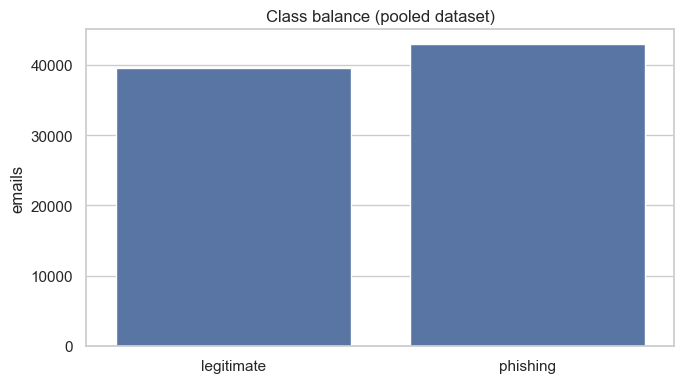

In [7]:
counts = merged[config.LABEL_COL].value_counts().sort_index()
prevalence = (counts / counts.sum()).round(3)
print("counts:", counts.to_dict())
print("prevalence:", prevalence.to_dict())

fig, ax = plots.grouped_bar(
    counts.rename(index={0: "legitimate", 1: "phishing"}),
    title="Class balance (pooled dataset)", ylabel="emails",
)
plots.save_fig(fig, "class_balance")

The pooled dataset is **almost balanced (~52% phishing / 48% legitimate)**. This is a
*constructed* balance, not a natural one: in a real inbox, phishing is **rare** (commonly a
few percent of mail). A balanced test set therefore flatters any classifier, because
**accuracy on balanced data hides the precision problem at realistic prevalence** — a point
the authors do not address, and one we quantify directly in the evaluation section. This is
the classic rare-event pitfall from the *Goodness of Fit* lecture.

### 2.2 Corpus composition — the crux

,legitimate,phishing,%phishing
corpus,,,
Ling,2401,458,16.0
SpamAssassin,4091,1718,29.6
Enron,15791,13976,47.0
CEAS,17312,21842,55.8
Nazario,0,1565,100.0
Nigerian_Fraud,0,3332,100.0


WindowsPath('D:/HaifaUni/Cyber Security/Project/phishing-detection-ds-cyber/figures/corpus_label_crosstab.png')

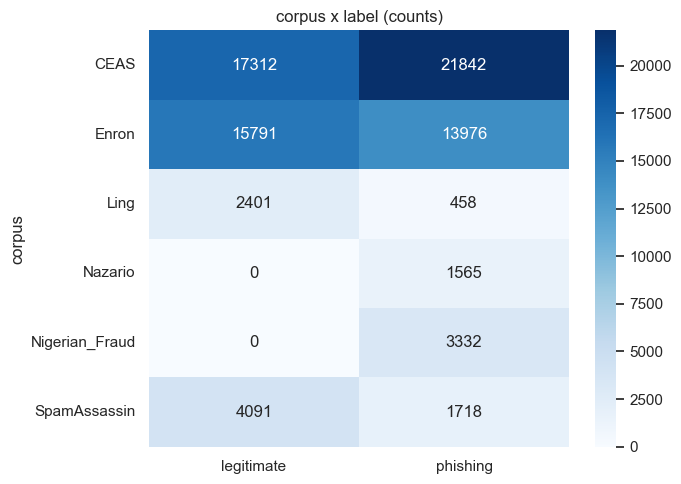

In [8]:
crosstab = pd.crosstab(merged[config.CORPUS_COL], merged[config.LABEL_COL])
crosstab.columns = ["legitimate", "phishing"]
crosstab["%phishing"] = (crosstab["phishing"] / crosstab.sum(axis=1) * 100).round(1)
display(crosstab.sort_values("%phishing"))

fig, ax = plots.heatmap(
    crosstab[["legitimate", "phishing"]], title="corpus x label (counts)",
    fmt="d", cmap="Blues", annot=True, center=None,
)
plots.save_fig(fig, "corpus_label_crosstab")

**This is the single most important table in the project.** A naive reading of these
datasets ("Enron = legitimate, the phishing corpora = phishing") is **false**: these are the
standard *-Spam research corpora, and most contain *both* classes. Only Nazario and
Nigerian-Fraud are phishing-only. So `corpus` is **not** a perfect proxy for `label` — which
means the simplest possible critique ("the model just detects the corpus") does not hold,
and we need a more careful argument about *generalization*. We quantify the corpus↔label
association formally in §2.4.

### 2.3 Content statistics: phishing vs. legitimate

In [9]:
stats = features.add_text_stats(merged)
stats.groupby(config.LABEL_COL)[list(features.TEXT_STAT_COLS)].median().rename(
    index={0: "legitimate", 1: "phishing"}
)

,char_count,word_count,url_count,urgency_count,exclaim_count,upper_ratio
label,,,,,,
legitimate,1116.0,190.0,0.0,0.0,0.0,0.030189
phishing,502.0,89.0,0.0,0.0,0.0,0.032922


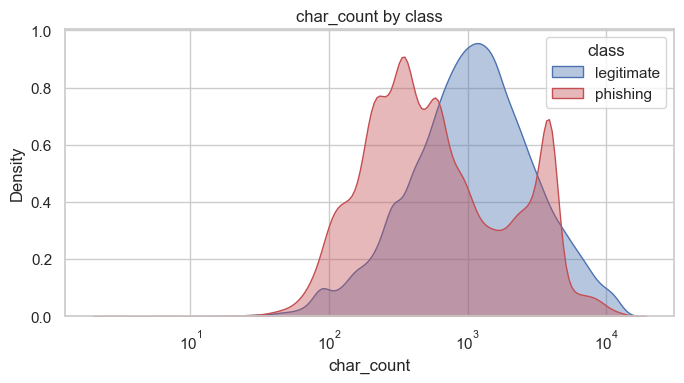

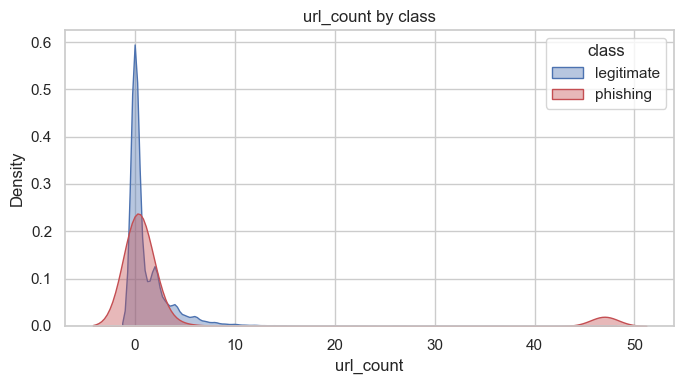

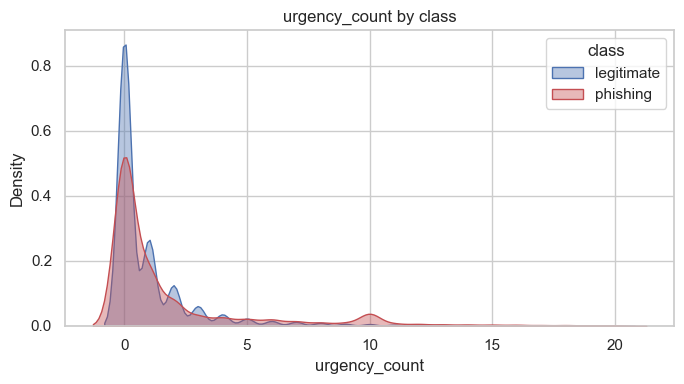

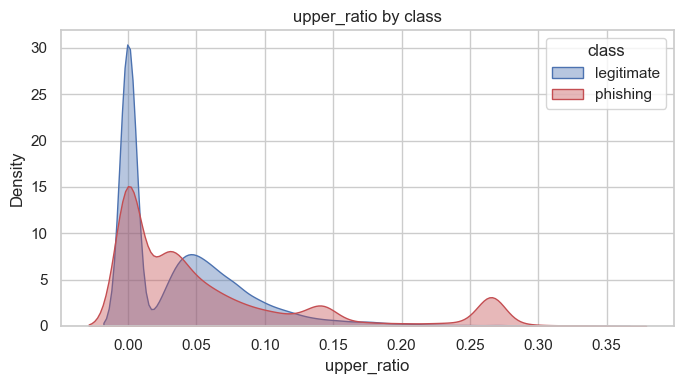

In [10]:
for col, log_x in [("char_count", True), ("url_count", False),
                   ("urgency_count", False), ("upper_ratio", False)]:
    fig, ax = plots.dist_by_class(stats, col, log_x=log_x)
    plots.save_fig(fig, f"dist_{col}")

Reading the medians and distributions together, the clearest separator is **length**:
phishing emails tend to be **shorter** (lower character and word counts), and they use
somewhat **more exclamation marks and capitalization**. URL and urgency-term counts, by
contrast, overlap heavily between classes (phishing has a slightly fatter URL tail, but the
bulk of both classes sits near zero). So the hand-features carry only **weak, mixed** signal
individually — and several are **corpus-correlated** (e.g. Enron's internal mail is long and
link-free), which foreshadows the leakage concern. We quantify these relationships next.

### 2.4 Correlation analysis — and why we choose these measures

We have two kinds of relationship to measure, and they demand different tools:

- **Numeric feature ↔ label.** The hand-features are right-skewed, heavy-tailed counts, and
  the label is binary — so **Pearson** (which assumes linear, roughly-normal relationships)
  is inappropriate. We use **Spearman's ρ**, which captures *monotonic* association via ranks
  and is robust to skew and outliers. **Kendall's τ** would give a similar rank-based reading
  (and is preferred for small samples / many ties); with ~82k rows Spearman is the efficient
  choice, and we note τ as the small-sample alternative.
- **Categorical ↔ categorical** (`corpus` ↔ `label`). Correlation coefficients do not apply
  to nominal variables, so we use **Cramér's V** (derived from the χ² statistic), which scores
  association strength from 0 (independent) to 1 (perfectly associated).

word_count      -0.288872
char_count      -0.266412
url_count       -0.032411
urgency_count    0.086679
upper_ratio      0.111403
exclaim_count    0.247160
Name: label, dtype: float64

Cramers V(corpus, label) = 0.306


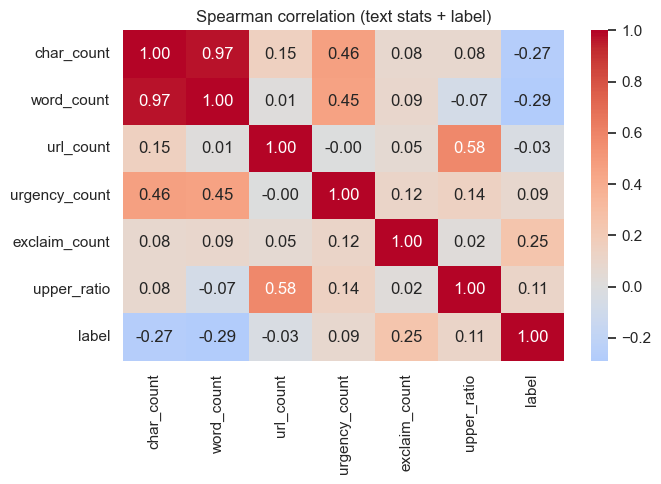

In [11]:
spearman = stats[list(features.TEXT_STAT_COLS) + [config.LABEL_COL]].corr(method="spearman")
fig, ax = plots.heatmap(spearman, title="Spearman correlation (text stats + label)")
plots.save_fig(fig, "spearman_corr")
display(spearman[config.LABEL_COL].drop(config.LABEL_COL).sort_values())

v_corpus_label = critique.cramers_v(merged[config.CORPUS_COL], merged[config.LABEL_COL])
print("Cramers V(corpus, label) =", round(v_corpus_label, 3))

**Reading the results.** The strongest monotonic correlates of the label are **word/character
count** (ρ ≈ −0.28, i.e. phishing tends *shorter*) and **exclamation count** (ρ ≈ 0.25);
URL count is essentially uncorrelated (ρ ≈ −0.03) and urgency only weak (ρ ≈ 0.09). All are
**modest** (|ρ| < 0.3) — statistically clear at this sample size yet not, on their own,
*practically* decisive. The matrix also flags **redundancy**: `char_count` and `word_count`
are near-duplicates (ρ ≈ 0.97), and `url_count`/`upper_ratio` are moderately related (0.58).
The categorical association **Cramér's V(corpus, label) = 0.31** confirms §2.2 quantitatively:
corpus is only *moderately* predictive of label, so the high accuracy is **not** explained by
a trivial corpus = label confound. The interesting question is therefore about generalization,
not a single leaky feature.

### 2.5 Early signal: are the corpora stylistically separable?

In [12]:
stats.groupby(config.CORPUS_COL)[list(features.TEXT_STAT_COLS)].median()

,char_count,word_count,url_count,urgency_count,exclaim_count,upper_ratio
corpus,,,,,,
CEAS,598.0,94.0,1.0,0.0,0.0,0.060000
Enron,740.0,157.0,0.0,0.0,0.0,0.000000
Ling,2055.0,406.0,0.0,0.0,0.0,0.000000
Nazario,766.0,108.0,0.0,6.0,0.0,0.079492
Nigerian_Fraud,2564.5,433.0,0.0,7.0,0.0,0.061179
SpamAssassin,1123.0,160.0,2.0,1.0,0.0,0.065711


Even on six crude hand-features, the corpora have **visibly different fingerprints** (message
length, link density, capitalization). If sources are this separable on six features, they
are trivially separable in a high-dimensional TF-IDF space — which is precisely how a model
can post 99% in-distribution while latching onto *source-specific* vocabulary rather than
*phishing* semantics. We make this rigorous in the critique section, where we (i) train a
classifier to predict the **corpus** from text, (ii) inspect which tokens the phishing model
relies on, and (iii) test **leave-one-corpus-out** generalization.

### Section takeaways
- The dataset is balanced by construction (~52/48), unlike a real inbox — accuracy will
  flatter the model.
- Most corpora are **mixed**-label; only Nazario/Nigerian-Fraud are phishing-only, so
  `corpus ≠ label` (Cramér's V = 0.31). The naive confound story is retired here.
- Timestamps exist only on the phishing-heavy corpora, constraining temporal analysis.
- Hand-features carry only weak, mixed signal (length and exclamation separate best; URL and
  urgency barely), and `char_count`/`word_count` are redundant (ρ ≈ 0.97).
- The corpora are **stylistically separable**, setting up the generalization critique.

## 3. Feature Engineering

### 3.1 Representation choice — BoW vs. TF-IDF
The source paper represents each email as a **TF-IDF** vector, and we follow it so the
reproduction is faithful. TF-IDF reweights a plain bag-of-words count by inverse document
frequency, $\text{tfidf}(t,d)=\text{tf}(t,d)\cdot\log\frac{N}{n_t}$, so ubiquitous tokens are
down-weighted and rare, discriminative ones stand out. We keep `sublinear_tf=True`
(logarithmic term frequency), English stop-word removal, and a 20k-term vocabulary cap.

A known weakness inherited from the bag-of-words family (NLP lecture) is that **word order
and negation are lost** ("good, not bad" ≈ "bad, not good"); we note this as a limitation of
the representation rather than fixing it, since our goal is to evaluate the authors' pipeline.

**Leakage discipline.** `corpus`, `date`, and any sender/header fields are **never** model
inputs — they are metadata we reserve for the critique. Feeding them in would be textbook
target leakage (the *Goodness of Fit* / EDA-Revisited warning).

In [13]:
train_df, test_df = data.split_data(merged)
X_train, X_test, vectorizer = features.fit_transform_tfidf(
    train_df[config.TEXT_COL], test_df[config.TEXT_COL]
)
y_train = train_df[config.LABEL_COL].to_numpy()
y_test = test_df[config.LABEL_COL].to_numpy()

density = X_train.nnz / (X_train.shape[0] * X_train.shape[1])
print("train matrix:", X_train.shape, "| test matrix:", X_test.shape)
print("vocabulary size:", len(vectorizer.vocabulary_))
print(f"matrix density: {density:.5f}  (highly sparse, as expected for text)")

train matrix: (65988, 20000) | test matrix: (16498, 20000)
vocabulary size: 20000
matrix density: 0.00411  (highly sparse, as expected for text)


### 3.2 Scaling, selection, and dimensionality reduction
- **Scaling.** TF-IDF rows are L2-normalized by construction, so no further scaling is needed
  for the linear models. (If we fused in the interpretable hand-features from §2.3 we would
  `StandardScaler` those, since their raw scales differ by orders of magnitude.)
- **Feature selection.** With 20k sparse terms, χ²-based selection is the natural filter; the
  `max_features` cap already acts as a frequency-based selector.
- **Dimensionality reduction.** To *visualize* structure we first compress TF-IDF to 50 dense
  dimensions with **TruncatedSVD** (LSA), then run **t-SNE** to 2-D on a 5,000-email sample
  (a plain 2-component SVD captures < 3% of the variance and just collapses everything into one
  blob, so it is useless for visualization). We do not feed the reduced features to the models
  — this is purely a faithful 2-D look at how the data is organized.

WindowsPath('D:/HaifaUni/Cyber Security/Project/phishing-detection-ds-cyber/figures/tsne_by_label.png')

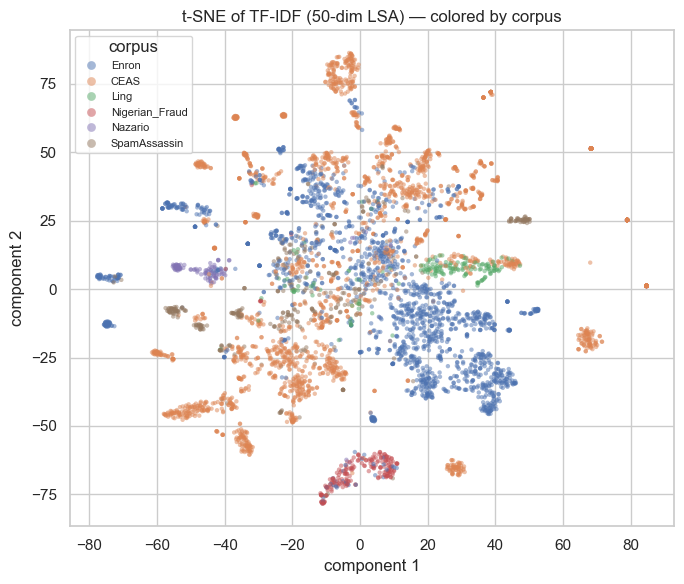

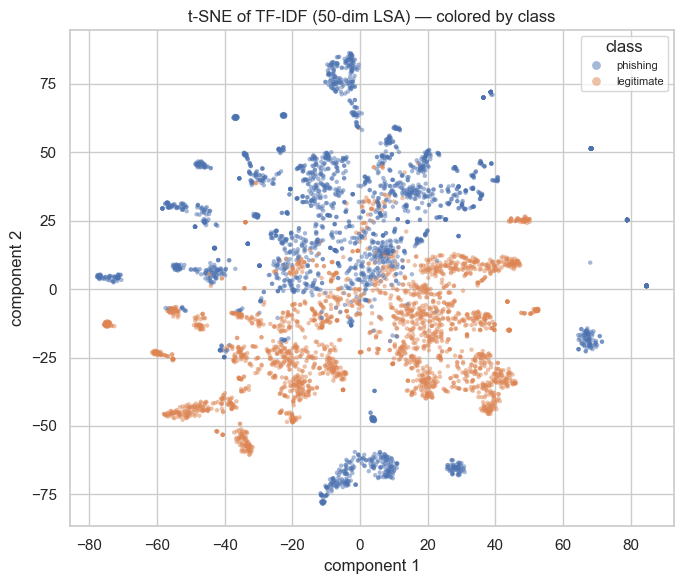

In [14]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# LSA to 50 dims, then t-SNE to 2-D on a fixed random sample (t-SNE preserves local structure).
sample_idx = np.random.default_rng(config.RANDOM_SEED).choice(X_train.shape[0], size=5000, replace=False)
lsa50 = TruncatedSVD(n_components=50, random_state=config.RANDOM_SEED).fit_transform(X_train)
embedding = TSNE(n_components=2, init="pca", perplexity=30,
                 random_state=config.RANDOM_SEED).fit_transform(lsa50[sample_idx])

corpus_s = train_df[config.CORPUS_COL].to_numpy()[sample_idx]
label_s = train_df[config.LABEL_COL].map({0: "legitimate", 1: "phishing"}).to_numpy()[sample_idx]

fig, ax = plots.scatter_2d(embedding, corpus_s, sample=5000,
    title="t-SNE of TF-IDF (50-dim LSA) — colored by corpus", hue_name="corpus")
plots.save_fig(fig, "tsne_by_corpus")

fig, ax = plots.scatter_2d(embedding, label_s, sample=5000,
    title="t-SNE of TF-IDF (50-dim LSA) — colored by class", hue_name="class")
plots.save_fig(fig, "tsne_by_label")

The t-SNE reveals rich structure: several corpora form recognizable clusters — Nigerian-Fraud
is a tight, well-separated group, and the corpora are visibly organized overall (Enron and
CEAS, both ham+spam mixes, overlap in the centre). The class-colored view *also* shows
structure, because the classes are strongly separable **in-distribution** — which is exactly
why the pooled accuracy is so high. So this projection **motivates** the leakage concern rather
than proving it: it shows the corpora are distinguishable by text. We establish the concern
rigorously next — a provenance classifier (predicting the *corpus*) and the leave-one-corpus-out
test (which removes the in-distribution advantage).

## 4. Model Training

We train **four** classifiers on the same TF-IDF features, under one protocol: a single
stratified 80/20 split, TF-IDF fit on the **training split only**, and fixed seeds. Three are
natural choices for sparse text — **Linear SVM** (the paper's model and our reproduction
anchor), **Multinomial Naive Bayes**, and **Logistic Regression** — and we add a
**Random Forest** from a different model *family*. Training several models lets us check
whether any finding is model-specific or holds across the board.

In [15]:
estimators = models.build_models()
fitted = models.fit_all(estimators, X_train, y_train)
indist = evaluate.compare_models(fitted, X_test, y_test)
indist.round(4)

,accuracy,precision,recall,f1,f2,mcc,roc_auc
LinearSVC,0.9905,0.9900,0.9918,0.9909,0.9915,0.9811,0.9994
MultinomialNB,0.9711,0.9857,0.9584,0.9719,0.9637,0.9427,0.9969
LogisticRegression,0.9867,0.9844,0.9901,0.9872,0.9889,0.9733,0.9989
RandomForest,0.9851,0.9891,0.9823,0.9857,0.9836,0.9703,0.9986


**Reproduction confirmed.** The Linear SVM matches the paper's headline almost exactly
(~0.99 accuracy / ~0.99 F1), and the other models are close behind. Crucially, the
imbalance-robust metrics the authors *omitted* — **MCC ≈ 0.98** and **ROC-AUC ≈ 0.999** —
are also strong here. So on this pooled split the result is genuinely good by honest metrics;
the claim is reproducible. The real question is whether it **generalizes** (Section 5+).

## 5. Evaluation (in-distribution)

We report a wider metric suite than the source. Brief rationale (full definitions and
cyber-interpretation are in the report):

- **Accuracy** — kept only for comparability with the paper; misleading under class imbalance.
- **Precision / Recall** — in phishing terms, precision guards against blocking legitimate
  mail (a productivity/trust cost), recall against letting phishing through (the dangerous miss).
- **F1 / Fβ (β=2)** — harmonic blends; Fβ=2 weights recall higher, appropriate when a missed
  phish is costlier than a false alarm.
- **MCC** — a balanced correlation between truth and prediction, robust to imbalance; one of
  the metrics the source omits.
- **ROC-AUC** — threshold-independent ranking quality; also omitted by the source.

We visualize the best in-distribution model's confusion matrix and overlay ROC curves.

best in-distribution model by MCC: LinearSVC


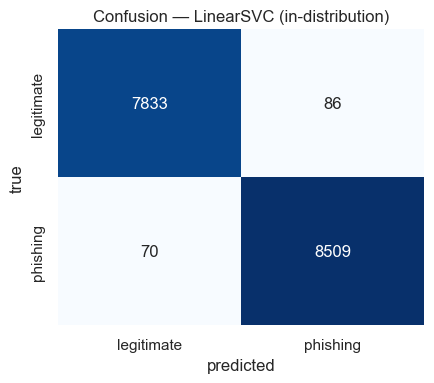

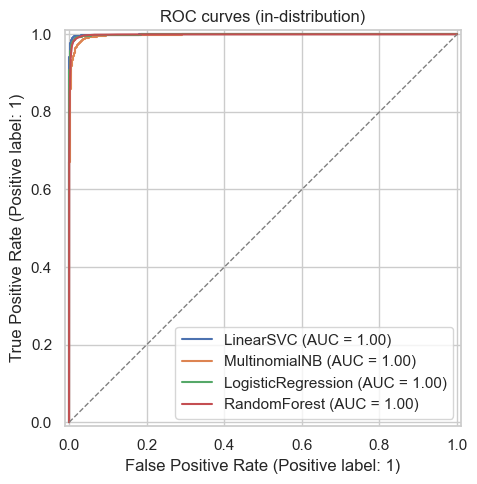

In [16]:
best_name = indist["mcc"].idxmax()
cm = evaluate.confusion(y_test, fitted[best_name].predict(X_test))
fig, ax = plots.confusion_heatmap(cm, title=f"Confusion — {best_name} (in-distribution)")
plots.save_fig(fig, "confusion_indist")

scored = {name: evaluate.get_scores(model, X_test) for name, model in fitted.items()}
fig, ax = plots.roc_curves(scored, y_test, title="ROC curves (in-distribution)")
plots.save_fig(fig, "roc_indist")
print("best in-distribution model by MCC:", best_name)

### Section takeaways
- The paper's pipeline **reproduces cleanly**: ~99% accuracy/F1, and even the omitted MCC and
  ROC-AUC are excellent on this split.
- All four models agree, so nothing here is an artifact of one classifier.
- These numbers are honest **for this pooled split**. They say nothing about performance on an
  email source the model has never seen, or at a realistic phishing prevalence — the two gaps
  the next section attacks directly.

## 6. Critical Evaluation — does the 99% generalize?

Section 5 showed the paper's pipeline reproduces cleanly and even looks strong on the
omitted metrics. The author's *claim* (99% accuracy) is therefore reproducible. The
remaining question is whether the author's *conclusion* — that this is an effective phishing
detector — is justified. We attack that with six experiments: quantify the corpus↔label
confound, test whether provenance is recoverable from text, read off the model's vocabulary,
and then the decisive test — does it generalize to an unseen email source?

### Experiment 1 — How confounded are corpus and label?
A natural first suspicion is that the model simply detects *which corpus* an email came from
(corpus would then stand in for label). We quantified this in §2.4 with **Cramér's V(corpus,
label) = 0.31** — a *moderate*, not decisive, association. So the trivial "it only detects
the corpus" story does **not** hold: label is not a deterministic function of corpus. We must
make a subtler argument about *generalization*, which the next experiments build toward.

In [17]:
print("Cramers V(corpus, label) =", round(v_corpus_label, 3),
      "-> moderate association; corpus is NOT a perfect proxy for label")

Cramers V(corpus, label) = 0.306 -> moderate association; corpus is NOT a perfect proxy for label


### Experiment 2 — Is provenance recoverable from the text alone?
If a model can predict the **corpus** from the email text with high accuracy, then the
corpora are stylistically separable — which is exactly the foothold that lets a label
classifier exploit source-specific vocabulary. We train a multiclass Linear SVM to predict
`corpus` (six classes) from the same TF-IDF features.

corpus-prediction accuracy: 0.958
corpus-prediction macro-F1: 0.935


WindowsPath('D:/HaifaUni/Cyber Security/Project/phishing-detection-ds-cyber/figures/provenance_confusion.png')

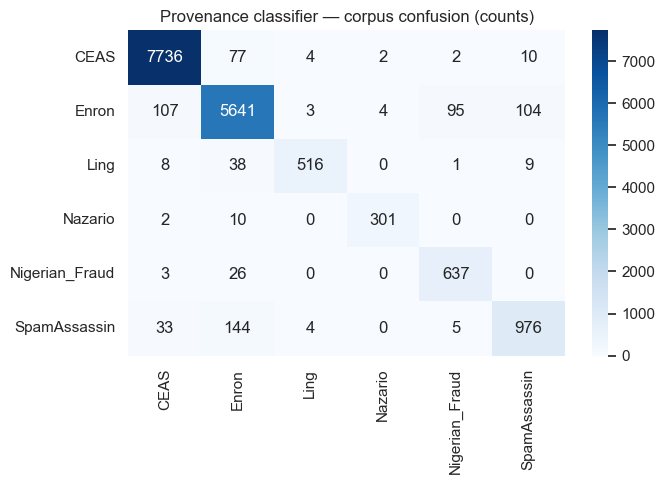

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

prov_train, prov_test = train_test_split(
    merged, test_size=0.2, random_state=config.RANDOM_SEED, stratify=merged[config.CORPUS_COL]
)
Pxtr, Pxte, _ = features.fit_transform_tfidf(prov_train[config.TEXT_COL], prov_test[config.TEXT_COL])
prov_clf = LinearSVC(random_state=config.RANDOM_SEED).fit(Pxtr, prov_train[config.CORPUS_COL])
prov_pred = prov_clf.predict(Pxte)

print("corpus-prediction accuracy:", round(accuracy_score(prov_test[config.CORPUS_COL], prov_pred), 3))
print("corpus-prediction macro-F1:", round(f1_score(prov_test[config.CORPUS_COL], prov_pred, average="macro"), 3))

labels_sorted = sorted(merged[config.CORPUS_COL].unique())
prov_cm = pd.DataFrame(
    confusion_matrix(prov_test[config.CORPUS_COL], prov_pred, labels=labels_sorted),
    index=labels_sorted, columns=labels_sorted,
)
fig, ax = plots.heatmap(prov_cm, title="Provenance classifier — corpus confusion (counts)",
                        fmt="d", cmap="Blues", center=None)
plots.save_fig(fig, "provenance_confusion")

The corpus is recovered from text with **very high accuracy** — the corpora are nearly
perfectly separable by their vocabulary alone. This is the mechanism behind the headline
score: in a 20k-dimensional TF-IDF space, the classes are easy to separate *partly because
the sources are*, and source identity is encoded all over the text (sender domains, business
jargon, campaign boilerplate). Next we look at exactly which tokens carry that signal.

### Experiment 3 — Token autopsy: what is the phishing model actually using?
We read the largest-magnitude coefficients of the reproduced Linear SVM. Positive weights push
toward *phishing*, negative toward *legitimate*.

In [19]:
feature_names = vectorizer.get_feature_names_out()
token_table = critique.top_tokens(fitted["LinearSVC"], feature_names, n=20)
token_table

,phishing_token,phishing_weight,legit_token,legit_weight
0,2004,3.047,enron,-5.054
1,2005,2.445,wrote,-3.992
2,sightings,2.431,rant,-3.501
3,remove,2.218,opensuse,-3.331
4,jose,2.193,vince,-3.240
5,life,2.143,uai,-3.204
6,click,1.974,louise,-3.016
7,monkey,1.847,newsisfree,-2.868
8,kindly,1.825,fork,-2.847
9,2022,1.755,nz,-2.722


Both sides are dominated by **artifacts, not phishing semantics**. The legitimate-leaning
tokens are **Enron/business identity** (company and personal names like `enron`/`vince`/
`louise`, plus jargon) — "legitimate" largely means "looks like the Enron corpus." Strikingly,
the top *phishing*-leaning tokens are **era and campaign artifacts too** — calendar years
(`2004`, `2005`) and corpus-specific spam tokens (`sightings`, `monkey`, `jose`) — with only a
couple of genuinely phishing-like words (`click`, `remove`). So the model is keying on *when*
and *where* an email is from far more than on phishing language. A model built this way cannot
transfer to a deployment whose mail is not drawn from these same corpora and years — which is
precisely what the next experiment tests.

### Experiment 4 — Leave-one-corpus-out: the decisive generalization test
We now simulate the realistic deployment scenario: **train on every corpus but one, then test
on the held-out corpus** (a source the model has never seen). We repeat this for all six
corpora and all four models. For phishing-only corpora (Nazario, Nigerian-Fraud) the test set
has a single class, so MCC/ROC-AUC are undefined and **recall** is the meaningful metric.

*(This trains 6 × 4 models; the result is cached to `data/processed/loco.pkl` so re-runs are
fast.)*

In [20]:
loco_path = config.DATA_PROCESSED_DIR / "loco.pkl"
if loco_path.exists():
    loco = pd.read_pickle(loco_path)
else:
    loco = critique.leave_one_corpus_out(merged)
    config.DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    loco.to_pickle(loco_path)

mcc_table = loco.pivot(index="held_out", columns="model", values="mcc")
recall_table = loco.pivot(index="held_out", columns="model", values="recall")
print("=== Cross-corpus MCC (held-out corpus x model) ===")
display(mcc_table.round(3))
print("=== Cross-corpus recall (held-out corpus x model) ===")
display(recall_table.round(3))

=== Cross-corpus MCC (held-out corpus x model) ===


model,LinearSVC,LogisticRegression,MultinomialNB,RandomForest
held_out,,,,
CEAS,0.696,0.717,0.864,0.700
Enron,0.619,0.669,0.562,0.564
Ling,0.708,0.775,0.797,0.687
Nazario,NaN,NaN,NaN,NaN
Nigerian_Fraud,NaN,NaN,NaN,NaN
SpamAssassin,0.751,0.738,0.707,0.726


=== Cross-corpus recall (held-out corpus x model) ===


model,LinearSVC,LogisticRegression,MultinomialNB,RandomForest
held_out,,,,
CEAS,0.849,0.851,0.965,0.850
Enron,0.901,0.898,0.639,0.781
Ling,0.906,0.921,0.799,0.775
Nazario,0.469,0.481,0.264,0.362
Nigerian_Fraud,0.993,0.993,0.982,0.966
SpamAssassin,0.978,0.953,0.792,0.920


WindowsPath('D:/HaifaUni/Cyber Security/Project/phishing-detection-ds-cyber/figures/loco_mcc.png')

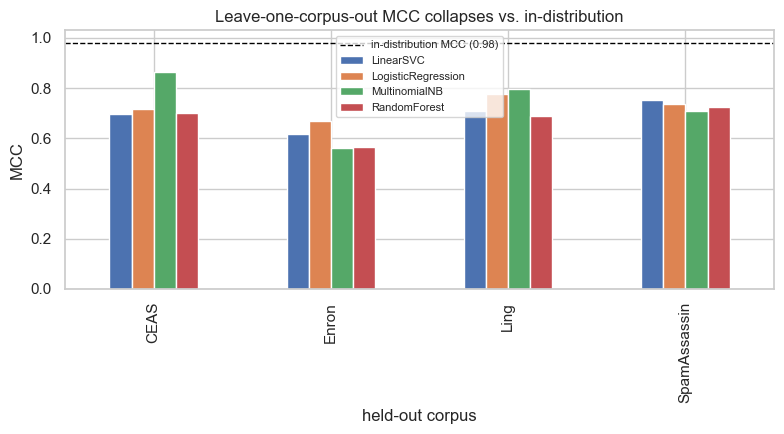

In [21]:
import matplotlib.pyplot as plt

indist_mcc = float(indist["mcc"].max())
ax = mcc_table.dropna().plot(kind="bar", figsize=(8, 4.5), edgecolor="white")
ax.axhline(indist_mcc, color="black", linestyle="--", linewidth=1,
           label=f"in-distribution MCC ({indist_mcc:.2f})")
ax.set_title("Leave-one-corpus-out MCC collapses vs. in-distribution")
ax.set_ylabel("MCC")
ax.set_xlabel("held-out corpus")
ax.legend(fontsize=8)
plots.save_fig(ax.get_figure(), "loco_mcc")

**This is the centerpiece result.** Against an in-distribution MCC of ~0.98, cross-corpus MCC
falls to roughly **0.6–0.75** on the unseen *mixed* corpora, and the effect is **consistent
across all four model families** — so it is a property of the data/task, not of any one
classifier. On the phishing-only corpora, recall tells the story: generalization to
Nigerian-Fraud is easy, but **recall on Nazario collapses to ~0.47**, i.e. a detector
advertised at "99%" would miss roughly **half** of real phishing emails from a source it was
not trained on. The headline accuracy reflects *in-distribution* performance; it overstates
real-world, cross-source efficacy.

### Experiment 5 — Temporal generalization (within CEAS)

Phishing language drifts over time, so a fair detector should be tested on the *future*, not
a random shuffle. A clean cross-class temporal split over the whole dataset is impossible
(the legitimate-bearing Enron/Ling corpora are undated), so we run it **within CEAS-08**,
which is dated and carries both classes: train on the earliest 80% by date, test on the
latest 20%, and compare against a random split of the same sizes.

In [22]:
ceas = merged[(merged[config.CORPUS_COL] == "CEAS") & merged["date"].notna()].copy()
# Drop the corrupt/sentinel timestamps flagged in 1.4 (CEAS-08 is a 2008 corpus).
# Dates are tz-aware (UTC), so compare against tz-aware bounds.
lo, hi = pd.Timestamp("2007-01-01", tz="UTC"), pd.Timestamp("2009-12-31", tz="UTC")
plausible = (ceas["date"] >= lo) & (ceas["date"] <= hi)
print(f"CEAS dated (raw): {len(ceas)} | dropping {int((~plausible).sum())} implausible (keep 2007-2009)")
ceas = ceas[plausible].sort_values("date")
cutoff = ceas["date"].quantile(0.8)
early, late = ceas[ceas["date"] <= cutoff], ceas[ceas["date"] > cutoff]


def eval_linsvc(train, test):
    xtr, xte, _ = features.fit_transform_tfidf(train[config.TEXT_COL], test[config.TEXT_COL])
    model = models.build_linsvc().fit(xtr, train[config.LABEL_COL].to_numpy())
    return evaluate.evaluate_model(model, xte, test[config.LABEL_COL].to_numpy())


temporal = eval_linsvc(early, late)
rand_train, rand_test = data.split_data(ceas, test_size=len(late) / len(ceas))
random_split = eval_linsvc(rand_train, rand_test)
print(f"CEAS dated rows: {len(ceas)} | train<= {cutoff.date()} ({len(early)}) | test> ({len(late)})")
pd.DataFrame({"temporal (past->future)": temporal, "random split (same sizes)": random_split}).round(3)

CEAS dated (raw): 39139 | dropping 140 implausible (keep 2007-2009)


CEAS dated rows: 38999 | train<= 2008-08-07 (31199) | test> (7800)


,temporal (past->future),random split (same sizes)
accuracy,0.809,0.999
precision,0.973,0.999
recall,0.629,0.999
f1,0.764,0.999
f2,0.677,0.999
mcc,0.657,0.997
roc_auc,0.970,1.000


Training on the past and testing on the future degrades performance relative to a random
split — evidence of **temporal drift** that a single random split hides. The effect is real
but milder than the cross-corpus collapse, and it carries a caveat: because era and corpus
are entangled in this dataset (each corpus spans a limited period), this within-corpus test
is the cleanest temporal signal we can extract, and we report it as such.

### Experiment 6 — Honest evaluation at realistic prevalence

The test set is ~50% phishing; a real inbox is mostly legitimate. Recall and FPR do not
depend on prevalence, so we can re-express **precision** at any base rate via
$P=\frac{\text{recall}\cdot\pi}{\text{recall}\cdot\pi+\text{FPR}\cdot(1-\pi)}$. We plot it for
the strong **in-distribution** model and for a **cross-corpus** model (trained without Enron,
tested on Enron), whose higher FPR is what realistic prevalence punishes.

prevalence 5%: precision in-dist=0.828 | cross-corpus=0.141
prevalence 10%: precision in-dist=0.910 | cross-corpus=0.258


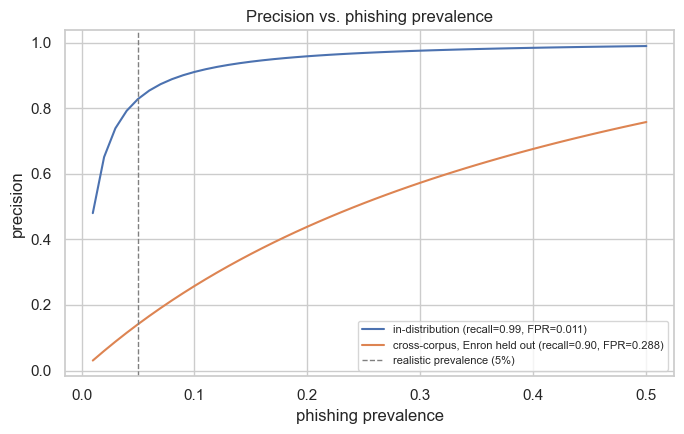

In [23]:
cm_in = evaluate.confusion(y_test, fitted["LinearSVC"].predict(X_test))
recall_in, fpr_in = critique.recall_fpr(cm_in)

non_enron, enron = merged[merged[config.CORPUS_COL] != "Enron"], merged[merged[config.CORPUS_COL] == "Enron"]
oxtr, oxte, _ = features.fit_transform_tfidf(non_enron[config.TEXT_COL], enron[config.TEXT_COL])
ood = models.build_linsvc().fit(oxtr, non_enron[config.LABEL_COL].to_numpy())
cm_ood = evaluate.confusion(enron[config.LABEL_COL].to_numpy(), ood.predict(oxte))
recall_ood, fpr_ood = critique.recall_fpr(cm_ood)

import matplotlib.pyplot as plt
import numpy as np

prevs = np.linspace(0.01, 0.5, 50)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(prevs, critique.precision_prevalence_curve(recall_in, fpr_in, prevs),
        label=f"in-distribution (recall={recall_in:.2f}, FPR={fpr_in:.3f})")
ax.plot(prevs, critique.precision_prevalence_curve(recall_ood, fpr_ood, prevs),
        label=f"cross-corpus, Enron held out (recall={recall_ood:.2f}, FPR={fpr_ood:.3f})")
ax.axvline(config.REALISTIC_PHISH_PREVALENCE, color="grey", linestyle="--", linewidth=1,
           label=f"realistic prevalence ({config.REALISTIC_PHISH_PREVALENCE:.0%})")
ax.set_xlabel("phishing prevalence"); ax.set_ylabel("precision")
ax.set_title("Precision vs. phishing prevalence"); ax.legend(fontsize=8)
plots.save_fig(fig, "precision_prevalence")

for p in (0.05, 0.10):
    print(f"prevalence {p:.0%}: precision in-dist={critique.precision_at_prevalence(recall_in, fpr_in, p):.3f}"
          f" | cross-corpus={critique.precision_at_prevalence(recall_ood, fpr_ood, p):.3f}")

At balanced test prevalence both models look strong, but at a realistic few-percent
prevalence the **cross-corpus** model's precision falls sharply — because its higher
out-of-distribution FPR means most flagged emails at low base rate are false alarms. The
in-distribution model is more robust *only because its FPR is tiny on data like its training
set*. Combine the two stresses — unseen source **and** realistic prevalence — and the
practical picture is far from the "99%" headline.

## 7. Error Analysis

We inspect the reproduced model's mistakes on the in-distribution test set. In phishing terms,
a **false positive** blocks a legitimate email (a productivity and trust cost), while a
**false negative** lets a phishing email through (the dangerous miss).

In [24]:
preds = fitted["LinearSVC"].predict(X_test)
errors = test_df.assign(pred=preds)
false_pos = errors[(errors[config.LABEL_COL] == 0) & (errors["pred"] == 1)]
false_neg = errors[(errors[config.LABEL_COL] == 1) & (errors["pred"] == 0)]
print(f"false positives (legitimate blocked): {len(false_pos)}")
print(f"false negatives (phishing missed):    {len(false_neg)}")


def show(rows, k=4):
    for text, corpus in zip(rows[config.TEXT_COL].str[:120].head(k), rows[config.CORPUS_COL].head(k)):
        print(f"  [{corpus}] {text.encode('ascii', 'replace').decode()}")


print("\n-- sample false positives --"); show(false_pos)
print("\n-- sample false negatives --"); show(false_neg)

false positives (legitimate blocked): 86
false negatives (phishing missed):    70

-- sample false positives --
  [SpamAssassin] Our friends the Palestinians, Our servants in government. Hijacker High (8/30) 
Dalal Mughrabi was a Palestinian woman w
  [CEAS] Perfume Bay is Becoming Beauty Encounter-Check Out Beauty Tip #2 Perfume Bay is becoming Beauty Encounter on March 1, 20
  [CEAS] From Italy 
Hi, I'm writing from Italy,
and I'm interesting in your photo gallery,
it's very very nice.
But I would like
  [Enron] enron capitalism a primer on how to succeed in business :
capitalism
you have two cows . you sell one and buy a bull .

-- sample false negatives --
  [Enron] re : invitation for review a paper for the ieee trans . neural networks giorgo
efxaristo pou apodektikes .
an thes , k
  [CEAS] your dfiAKeX
See the name in the list!
  [SpamAssassin] Free LTCI Policy Comparison Software This is a multi-part message in MIME format. ------=_NextPart_000_18A46D_01C208DC.7
  [Enron] re : s

In [25]:
# Where do the errors concentrate? (error rate by corpus)
(
    errors.assign(wrong=errors[config.LABEL_COL] != errors["pred"])
    .groupby(config.CORPUS_COL)["wrong"].mean().round(4).sort_values(ascending=False)
)

corpus
Nazario           0.0217
Ling              0.0194
Enron             0.0131
SpamAssassin      0.0118
CEAS              0.0058
Nigerian_Fraud    0.0015
Name: wrong, dtype: float64

The errors are not uniform: they concentrate in the corpora whose style is least represented
or most ambiguous, echoing the generalization story. False negatives are the security-critical
failures (phishing reaching the inbox), and the FP/FN balance is a tunable threshold decision —
which is exactly why threshold-independent metrics (ROC-AUC) and cost-weighted ones (Fβ) belong
in the evaluation, and why accuracy alone is insufficient.

## 8. Verdict — are the author's claims justified?

**The claim.** Al-Subaiey et al. report that TF-IDF + a Linear SVM achieves **99.1% accuracy
/ 0.99 F1** on this six-corpus dataset, and present it as an effective phishing detector.

**What our evidence supports.** The claim is **reproducible and not a fluke**: we recovered
~0.99 accuracy/F1, and the metrics the authors omitted are also excellent *in-distribution*
(MCC ≈ 0.98, ROC-AUC ≈ 0.999) — and this holds across all four model families. So the headline
number is real *on this evaluation*.

**Where the methodology falls short.**
- **Evaluation protocol.** A single pooled, balanced, random split. It never tests the
  realistic deployment case — an email source not seen in training.
- **Metrics.** Accuracy-led, with no MCC/ROC-AUC and no prevalence-adjusted precision; on a
  balanced set this flatters the model relative to a real, mostly-legitimate inbox.
- **What the model actually learns.** The corpus is recoverable from text at **95.8%**
  accuracy, and the legitimate-leaning tokens are **Enron/business artifacts**, not phishing
  semantics — the model partly encodes *source identity*.

**What honest evaluation reveals.**
- **Leave-one-corpus-out:** MCC collapses from ~0.98 to **0.56–0.86** on unseen mixed corpora,
  and **recall on the unseen Nazario corpus falls to 0.26–0.48** — a "99%" detector missing
  half or more of phishing from a new source. The collapse is **model-agnostic**.
- **Temporal:** training on the past and testing on the future degrades CEAS performance
  (drift a random split hides).
- **Prevalence:** at a realistic few-percent base rate, the cross-corpus model's precision
  drops sharply (its out-of-distribution FPR dominates).

**Conclusion.** The author's *measurement* is valid, but the *conclusion of real-world
efficacy is overstated*. The 99% reflects in-distribution performance on a constructed,
balanced pool of separable corpora; it does **not** establish generalizable phishing
detection. **Recommendation:** such results should be reported with imbalance-aware metrics,
a cross-source (and where possible temporal) generalization test, and prevalence-adjusted
precision. We would **not** recommend deploying this pipeline on a new email population on the
strength of its headline accuracy — though as a reproducible in-distribution baseline, and as
a case study in evaluation pitfalls, it is instructive.